# 03 — Gradient Boosting (XGBoost / LightGBM) por Cluster
**Rol:** Mejor rendimiento predictivo estado del arte. Se usa para validar que la
señal SHAP del RF es estable, y para identificar interacciones que ningún modelo
más simple captura.

---
Se entrena XGBoost y, si está disponible, LightGBM. Se compara la ganancia de AUC
sobre la Regresión Logística para determinar si la complejidad adicional se justifica
dentro de cada cluster.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, recall_score, f1_score, precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.impute   import SimpleImputer
from sklearn.preprocessing import StandardScaler
import time

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data')
IMG_DIR  = Path('../../results/figures/clusters'); IMG_DIR.mkdir(parents=True, exist_ok=True)
CLUSTERED_CSV = DATA_DIR / 'dataset_clustered.csv'

assert CLUSTERED_CSV.exists(), (
    "No se encontró dataset_clustered.csv — ejecutar 00_cluster_profiles.ipynb primero"
)

df = pd.read_csv(CLUSTERED_CSV, low_memory=False)
print(f"✓ dataset_clustered.csv: {df.shape}")

# ── Constantes ────────────────────────────────────────────────────────────────
SEED         = 42
TARGET       = 'retention'
PRETEC21     = ['AD14','AD15','AD16','AD17','AD18']
TEC21        = ['AD19','AD20']
N_CLUSTERS   = df['cluster'].nunique()
MIN_AUC      = 0.60
SKF          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Features del modelo (excluir fuga y metadatos) ────────────────────────────
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS_BASE = [c for c in [
    'PNA','admission_test_norm','english.evaluation','admission.rubric','general.math.eval',
    'online.test','FTE','apoyo_financiero',
    'has_extracurriculars','has_physical','has_cultural','has_social',
    'first_gen_enc','educ_padres_max','parents_exatec_enc','socioec_enc','social_lag_enc',
    'age','is_male','estuvo_prepa_tec',
    'foreign_Yes: Foreigner','foreign_Yes: National',
    'zone_enc','zone_Rural','zone_Semiurban','zone_Urban',
    'school_enc','region_enc',
    'first_gen_present','parents_edu_present','took_admission_test',
    'has_socioeconomic_data','has_social_lag_data','has_zone_data',
] if c in df.columns and c not in EXCLUDE]

print(f"Features disponibles: {len(FEATURE_COLS_BASE)}")

# ── Paleta de clusters ────────────────────────────────────────────────────────
CLUSTER_COLORS = ['#2563eb','#dc2626','#16a34a','#f59e0b','#7c3aed','#0891b2']

# ── Helper: preparar datos de un cluster ──────────────────────────────────────
def get_cluster_data(cluster_id, regime=None):
    mask = df['cluster'] == cluster_id
    if regime == 'PreTec21':
        mask &= df['generation'].isin(PRETEC21)
    elif regime == 'Tec21':
        mask &= df['generation'].isin(TEC21)
    sub = df[mask].copy()
    feat_cols = [c for c in FEATURE_COLS_BASE if sub[c].std() > 0]
    imp = SimpleImputer(strategy='median')
    X   = imp.fit_transform(sub[feat_cols].values.astype(float))
    y   = sub[TARGET].values.astype(int)
    return X, y, feat_cols, sub

# ── Helper: evaluar modelo ────────────────────────────────────────────────────
def eval_model(model, X, y, model_name, feat_cols, seed=SEED):
    if len(np.unique(y)) < 2 or (y==0).sum() < 5:
        print(f"    ⚠ Insuficientes desertores — omitido")
        return None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:,1] if has_proba else None
    y_pred    = model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if (has_proba and len(np.unique(y_te))>1) else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    return dict(model=model_name, auc=auc, recall=rec, precision=prec, f1=f1,
                y_proba=y_proba, y_pred=y_pred, y_te=y_te, feat_cols=feat_cols,
                n_train=len(y_tr), n_test=len(y_te),
                dropout_rate=(y==0).mean(), trained_model=model)

print("\n✓ Setup completo — listo para entrenar modelos por cluster")

✓ dataset_clustered.csv: (77517, 39)
Features disponibles: 34

✓ Setup completo — listo para entrenar modelos por cluster


In [2]:
try:
    import xgboost as xgb; XGB_AVAILABLE = True
    print(f"✓ XGBoost {xgb.__version__}")
except ImportError:
    XGB_AVAILABLE = False
    print("⚠ XGBoost no disponible — pip install xgboost --break-system-packages")

try:
    import lightgbm as lgb; LGB_AVAILABLE = True
    print(f"✓ LightGBM {lgb.__version__}")
except ImportError:
    LGB_AVAILABLE = False
    print("⚠ LightGBM no disponible — pip install lightgbm --break-system-packages")

try:
    import shap; SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

✓ XGBoost 3.2.0
✓ LightGBM 4.6.0


## 1. XGBoost por cluster

In [3]:
results_xgb = {}

if XGB_AVAILABLE:
    for cluster_id in range(N_CLUSTERS):
        for regime_name, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                                   ('Tec21',   ['AD19','AD20'])]:
            key = (cluster_id, regime_name)
            X, y, feat_cols, sub = get_cluster_data(cluster_id, regime_name)
            if (y==0).sum() < 10 or len(y) < 50: continue

            spw = float((y==1).sum()) / max((y==0).sum(), 1)
            model = xgb.XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=spw, eval_metric='logloss',
                random_state=SEED, n_jobs=-1, verbosity=0
            )
            res = eval_model(model, X, y, 'XGBoost', feat_cols)
            if res is None: continue
            results_xgb[key] = res
            print(f"Cluster {cluster_id} [{regime_name}]  n={len(y):,}  "
                  f"AUC={res['auc']:.3f}  Recall={res['recall']:.3f}  "
                  f"{'✓' if res['auc']>=MIN_AUC else '⚠'}")
else:
    print("XGBoost no disponible")

Cluster 0 [PreTec21]  n=20,109  AUC=0.633  Recall=1.000  ✓
Cluster 0 [Tec21]  n=129  AUC=0.597  Recall=0.778  ⚠
Cluster 1 [PreTec21]  n=9,617  AUC=0.622  Recall=1.000  ✓


Cluster 1 [Tec21]  n=19,488  AUC=0.641  Recall=1.000  ✓
Cluster 2 [PreTec21]  n=2,643  AUC=0.670  Recall=1.000  ✓
Cluster 2 [Tec21]  n=3,129  AUC=0.667  Recall=0.993  ✓


Cluster 3 [PreTec21]  n=20,641  AUC=0.689  Recall=1.000  ✓
Cluster 3 [Tec21]  n=1,761  AUC=0.604  Recall=0.997  ✓


## 2. LightGBM por cluster

In [4]:
results_lgb = {}

if LGB_AVAILABLE:
    for cluster_id in range(N_CLUSTERS):
        for regime_name, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                                   ('Tec21',   ['AD19','AD20'])]:
            key = (cluster_id, regime_name)
            X, y, feat_cols, sub = get_cluster_data(cluster_id, regime_name)
            if (y==0).sum() < 10 or len(y) < 50: continue

            spw = float((y==1).sum()) / max((y==0).sum(), 1)
            model = lgb.LGBMClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=spw, random_state=SEED,
                n_jobs=-1, verbose=-1
            )
            res = eval_model(model, X, y, 'LightGBM', feat_cols)
            if res is None: continue
            results_lgb[key] = res
            print(f"Cluster {cluster_id} [{regime_name}]  n={len(y):,}  "
                  f"AUC={res['auc']:.3f}  Recall={res['recall']:.3f}  "
                  f"{'✓' if res['auc']>=MIN_AUC else '⚠'}")
else:
    print("LightGBM no disponible")

Cluster 0 [PreTec21]  n=20,109  AUC=0.611  Recall=1.000  ✓
Cluster 0 [Tec21]  n=129  AUC=0.625  Recall=0.778  ✓
Cluster 1 [PreTec21]  n=9,617  AUC=0.628  Recall=1.000  ✓


Cluster 1 [Tec21]  n=19,488  AUC=0.632  Recall=1.000  ✓
Cluster 2 [PreTec21]  n=2,643  AUC=0.675  Recall=1.000  ✓
Cluster 2 [Tec21]  n=3,129  AUC=0.652  Recall=1.000  ✓


Cluster 3 [PreTec21]  n=20,641  AUC=0.682  Recall=1.000  ✓
Cluster 3 [Tec21]  n=1,761  AUC=0.612  Recall=0.997  ✓


## 3. Comparación de modelos por cluster

In [5]:
# Cargar resultados LR y RF si existen (para comparación completa)
# Nota: si se ejecutan los notebooks en orden, puede reusar variables globales
# Si no: re-entrena LR y RF aquí de forma rápida
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

results_compare = {}  # {(cluster, regime, model_name): auc}

for cluster_id in range(N_CLUSTERS):
    for regime_name in ['PreTec21','Tec21']:
        key = (cluster_id, regime_name)
        X, y, feat_cols, _ = get_cluster_data(cluster_id, regime_name)
        if (y==0).sum() < 10 or len(y) < 50: continue

        # LR
        sc  = StandardScaler()
        X_s = sc.fit_transform(X)
        lr  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
        X_tr, X_te, y_tr, y_te = train_test_split(X_s, y, test_size=0.2, random_state=SEED, stratify=y)
        lr.fit(X_tr, y_tr)
        results_compare[(cluster_id, regime_name, 'LR')] = roc_auc_score(y_te, lr.predict_proba(X_te)[:,1])

        # RF
        rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        results_compare[(cluster_id, regime_name, 'RF')] = roc_auc_score(y_te, rf.predict_proba(X_te)[:,1])

        # XGB
        if key in results_xgb:
            results_compare[(cluster_id, regime_name, 'XGB')] = results_xgb[key]['auc']
        # LGB
        if key in results_lgb:
            results_compare[(cluster_id, regime_name, 'LGB')] = results_lgb[key]['auc']

# Tabla pivot
compare_rows = []
for (cl, reg, mname), auc in results_compare.items():
    compare_rows.append({'Cluster':cl,'Régimen':reg,'Modelo':mname,'AUC':round(auc,3)})
comp_df = pd.DataFrame(compare_rows)

for regime_name in ['PreTec21','Tec21']:
    pivot = comp_df[comp_df['Régimen']==regime_name].pivot(
        index='Cluster', columns='Modelo', values='AUC')
    print(f"\n═══ {regime_name} ═══")
    print(pivot.to_string())


═══ PreTec21 ═══
Modelo     LGB     LR     RF    XGB
Cluster                            
0        0.611  0.633  0.622  0.633
1        0.628  0.671  0.660  0.622
2        0.675  0.717  0.636  0.670
3        0.682  0.665  0.665  0.689

═══ Tec21 ═══
Modelo     LGB     LR     RF    XGB
Cluster                            
0        0.625  0.632  0.701  0.597
1        0.632  0.655  0.650  0.641
2        0.652  0.693  0.680  0.667
3        0.612  0.607  0.613  0.604


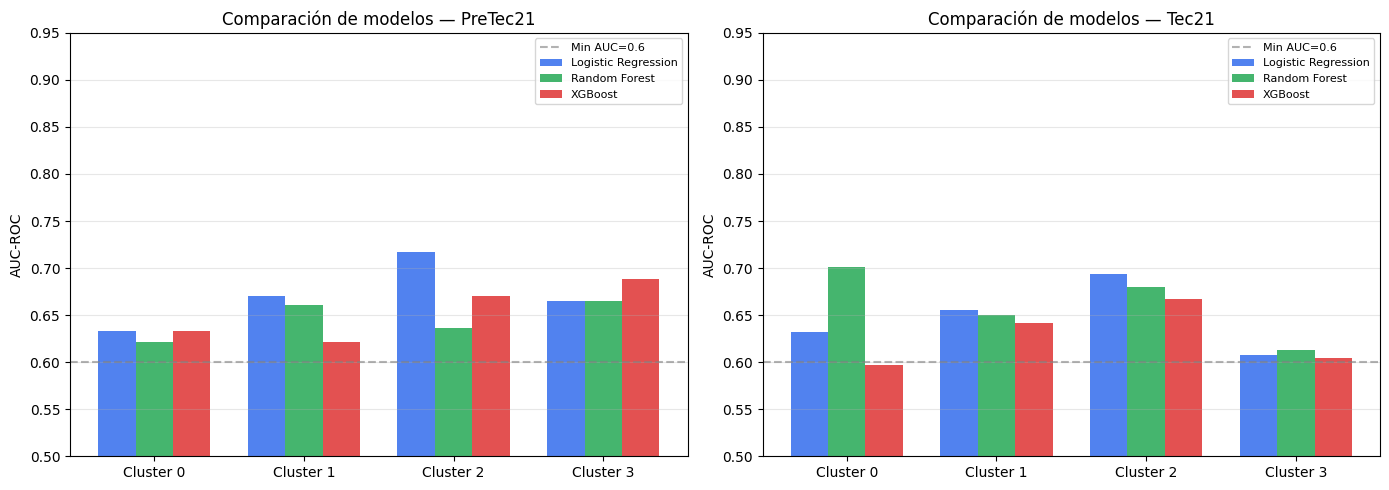

In [6]:
# Gráfico: ganancia de AUC sobre LR base (XGB vs LR)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, regime_name in zip(axes, ['PreTec21','Tec21']):
    clusters = range(N_CLUSTERS)
    lr_aucs  = [results_compare.get((k, regime_name, 'LR'), np.nan) for k in clusters]
    xgb_aucs = [results_compare.get((k, regime_name, 'XGB'), np.nan) for k in clusters]
    rf_aucs  = [results_compare.get((k, regime_name, 'RF'), np.nan) for k in clusters]

    x = np.arange(N_CLUSTERS); w = 0.25
    ax.bar(x-w, lr_aucs,  w, label='Logistic Regression', color='#2563eb', alpha=0.8)
    ax.bar(x,   rf_aucs,  w, label='Random Forest',        color='#16a34a', alpha=0.8)
    ax.bar(x+w, xgb_aucs, w, label='XGBoost',              color='#dc2626', alpha=0.8)
    ax.axhline(MIN_AUC, ls='--', color='gray', alpha=0.6, label=f'Min AUC={MIN_AUC}')
    ax.set_xticks(x); ax.set_xticklabels([f'Cluster {k}' for k in clusters])
    ax.set_ylabel('AUC-ROC'); ax.set_ylim(0.5, 0.95)
    ax.set_title(f'Comparación de modelos — {regime_name}')
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / 'gbm_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP — XGBoost por cluster

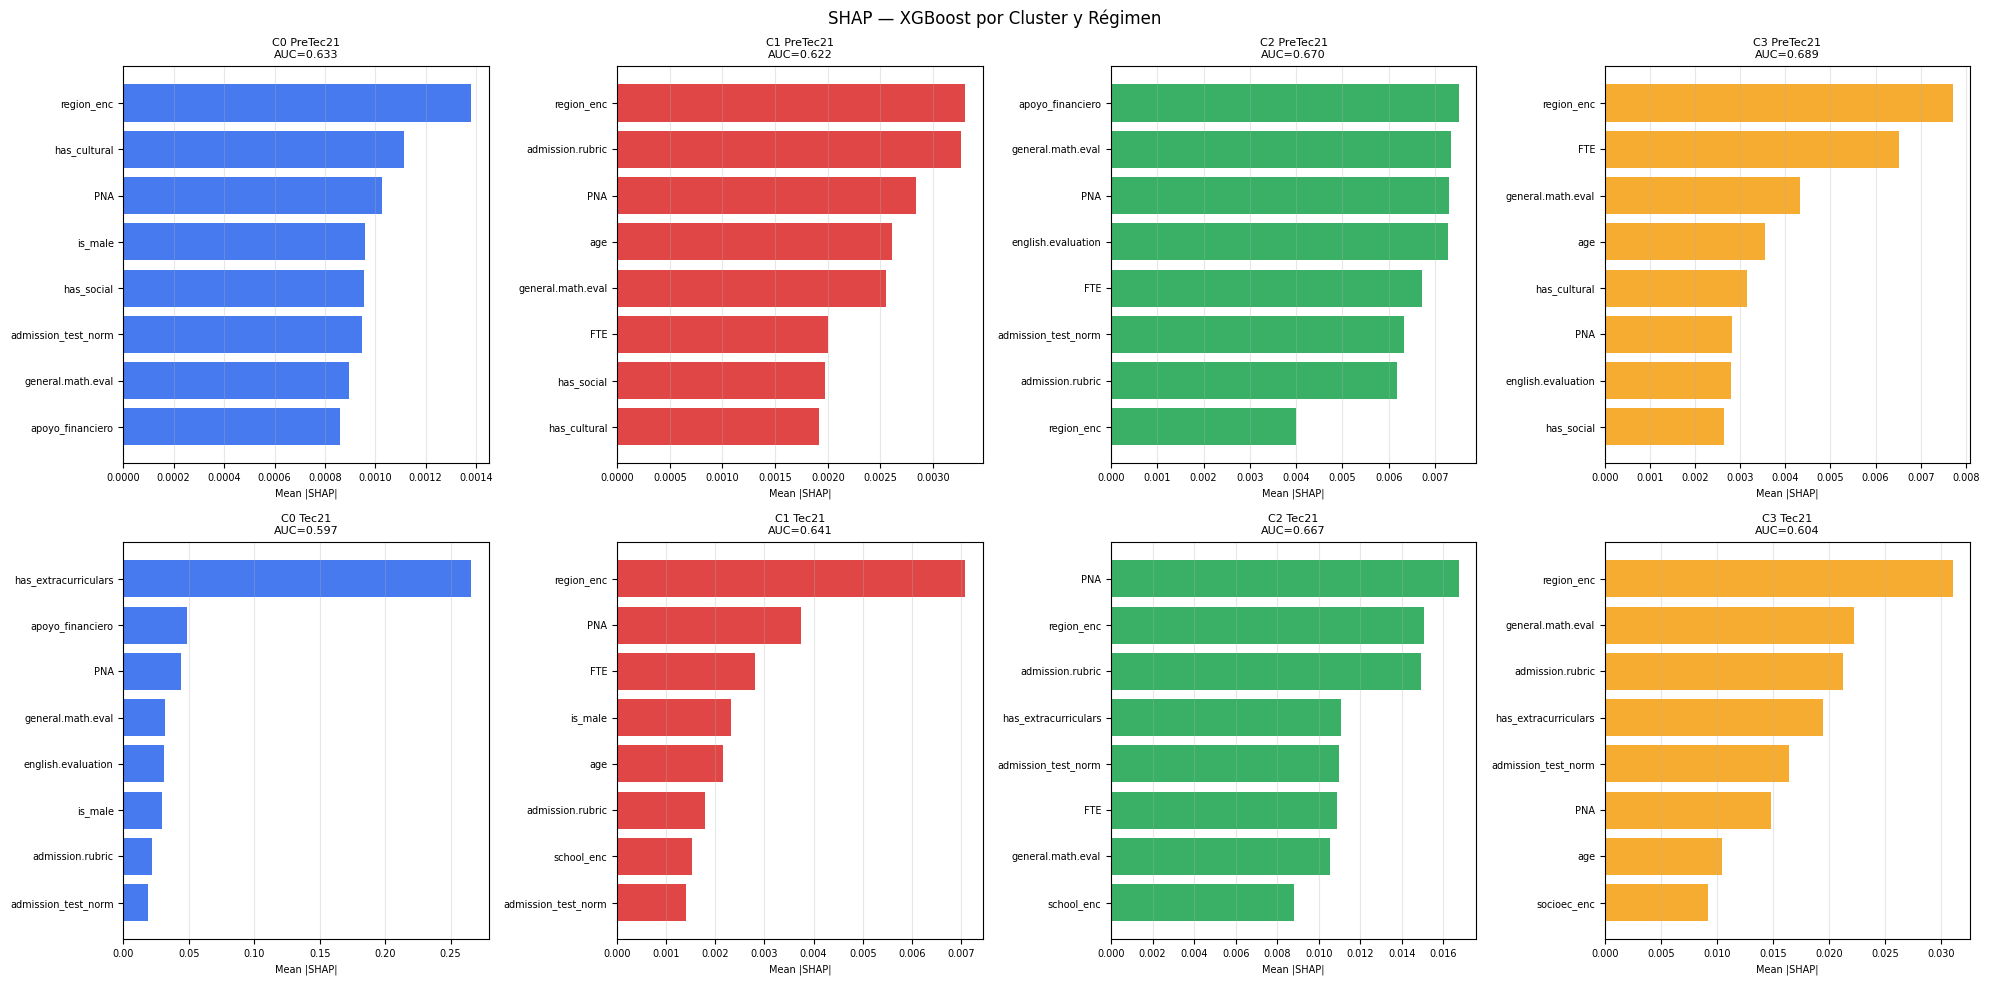

✓ SHAP chart guardado


In [7]:
# ── SHAP para XGBoost — usa shap.Explainer con predict_proba
# (TreeExplainer incompatible con XGBoost ≥3.x por formato base_score)
def xgb_shap_matrix(model, X_bg, X_explain):
    """Devuelve SHAP values (n_samples, n_features) para clase positiva."""
    pred_fn = lambda x: model.predict_proba(x)[:, 1]
    bg  = shap.maskers.Independent(X_bg[:min(50, len(X_bg))], max_samples=50)
    exp = shap.Explainer(pred_fn, bg)
    sv  = exp(X_explain)
    return sv.values   # (n_samples, n_features)

if SHAP_AVAILABLE and results_xgb:
    n_cols = N_CLUSTERS
    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 10))
    if n_cols == 1: axes = axes.reshape(2, 1)

    for row_i, regime_name in enumerate(['PreTec21', 'Tec21']):
        for col_i, k in enumerate(range(N_CLUSTERS)):
            ax = axes[row_i, col_i]
            key = (k, regime_name)
            if key not in results_xgb:
                ax.set_visible(False); continue
            res      = results_xgb[key]
            X_cl, _, feat_cols, _ = get_cluster_data(k, regime_name)
            n_sample = min(150, len(X_cl))
            rng      = np.random.default_rng(SEED)
            idx      = rng.choice(len(X_cl), n_sample, replace=False)
            sample   = X_cl[idx]
            try:
                sv_mat   = xgb_shap_matrix(res['trained_model'], X_cl, sample)
                mean_abs = np.abs(sv_mat).mean(axis=0)
                top_idx  = np.argsort(mean_abs)[::-1][:8]
                ax.barh([feat_cols[i] for i in top_idx], mean_abs[top_idx],
                        color=CLUSTER_COLORS[k], alpha=0.85)
                ax.invert_yaxis()
            except Exception as e:
                ax.text(0.5, 0.5, f'SHAP error:\n{e}', transform=ax.transAxes,
                        ha='center', va='center', fontsize=7, color='red')
            ax.set_title(f'C{k} {regime_name}\nAUC={res["auc"]:.3f}', fontsize=8)
            ax.set_xlabel('Mean |SHAP|', fontsize=7)
            ax.tick_params(labelsize=7); ax.grid(axis='x', alpha=0.3)

    plt.suptitle('SHAP — XGBoost por Cluster y Régimen', fontsize=12)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'xgb_shap_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ SHAP chart guardado")
elif not SHAP_AVAILABLE:
    print("SHAP no disponible — pip install shap --break-system-packages")
else:
    print("Sin resultados XGBoost para graficar")